In [29]:
import showerdata
from matplotlib import pyplot as plt
import matplotlib as mpl
import numpy as np

In [34]:
file_path = "/data/dust/user/dayhallh/data/AllShowers/sliced_geant4/geant4_1_of_200.h5"
sdf = showerdata.ShowerDataFile(file_path)


In [35]:
photons = []
needed = 20
for i in range(len(sdf)):
    item = sdf[i]
    if item.pdg[0] == 22:
        photons.append((item.directions, item.points))
    if len(photons) >= needed:
        break

In [36]:
def center_arrow(ax, dx, dy, frac=0.1, **arrowprops):
    bb = ax.get_window_extent()          # axes size in pixels
    r = bb.width / bb.height
    ux, uy = np.array([dx, dy]) / np.hypot(dx, dy)
    tip = (0.5 + frac * ux, 0.5 + frac * uy * r)
    ax.annotate("", xy=tip, xytext=(0.5, 0.5),
                xycoords=ax.transAxes, textcoords=ax.transAxes,
                arrowprops=dict(arrowstyle="-|>",
                                color="k", **arrowprops))


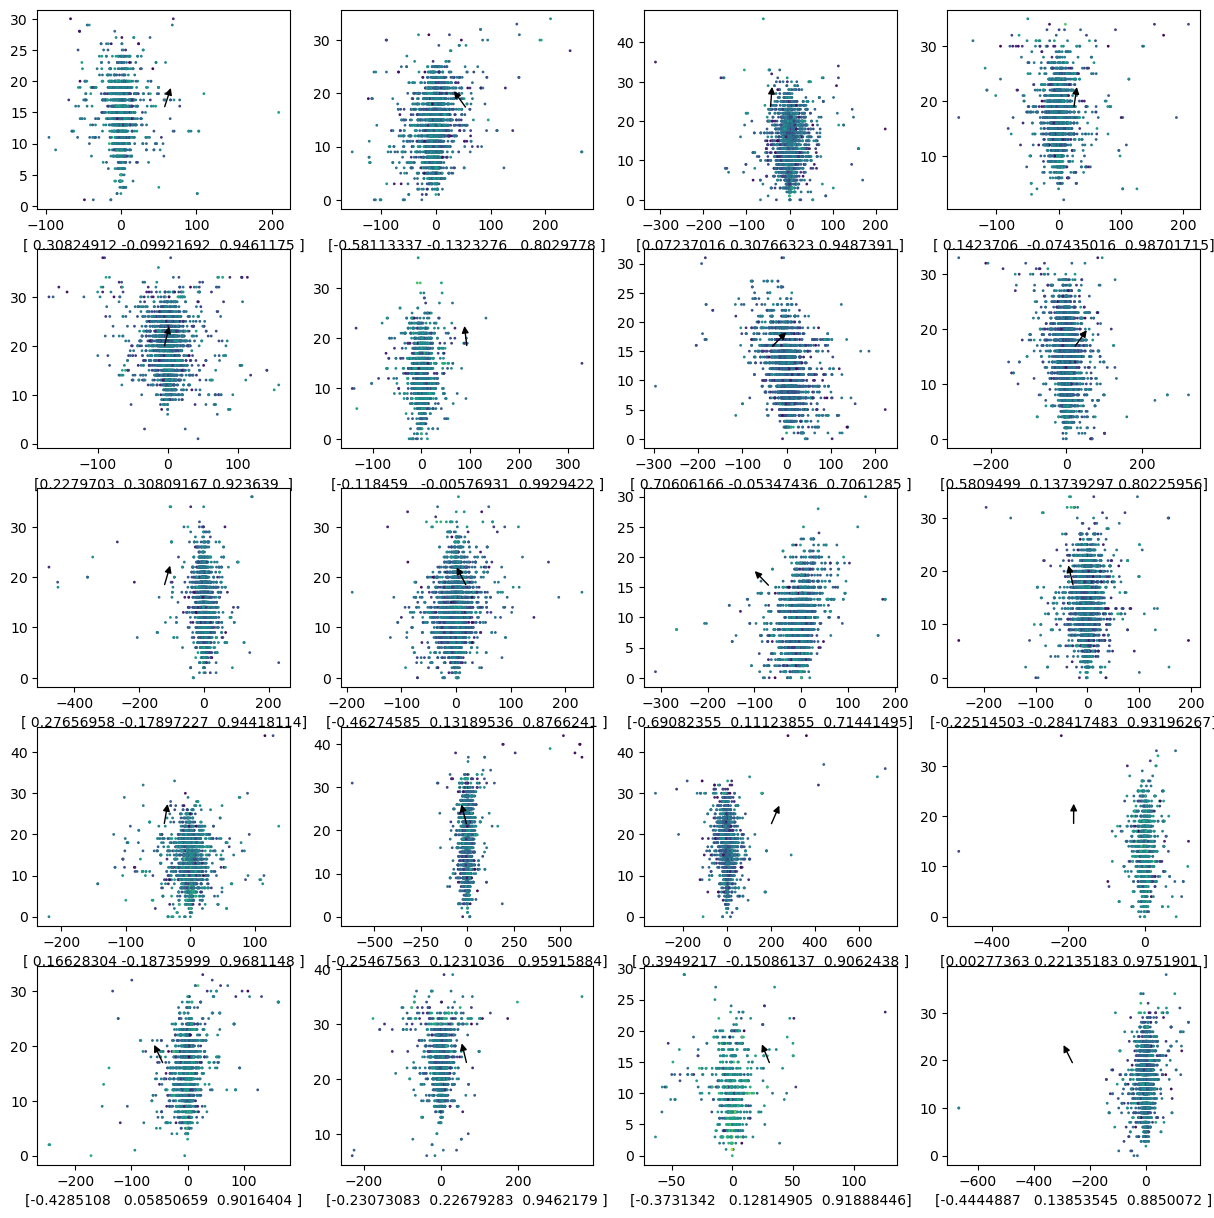

In [37]:
fig, axarr = plt.subplots(5, 4, figsize=(15, 15))

for i, ax in enumerate(axarr.flatten()):
    direction = (photons[i][0][0])
    ax.set_xlabel(direction)
    points = photons[i][1][0]
    lognorm_colour = mpl.colors.LogNorm(
        vmin=10**(-5), vmax=points[:, 3].max()
    )

    real_points = points[points[:, 3]>0]
    ax.scatter(real_points[:, 0], real_points[:, 2], c=real_points[:, 3], s=1, norm=lognorm_colour)
    center_arrow(ax, direction[0], direction[2])


In [39]:
len(item)


1

In [53]:
all_showers = sdf[:]
mine = all_showers.points

In [55]:
np.min(mine, axis=(0,1)), np.max(mine, axis=(0,1))

(array([-747.22833, -747.23926,    0.     ,    0.     ], dtype=float32),
 array([7.4723755e+02, 7.4723846e+02, 7.7000000e+01, 1.6806038e-01],
       dtype=float32))

In [56]:
np.mean(mine, axis=(0,1)), np.std(mine, axis=(0,1))

(array([1.6830610e-02, 2.6405392e-02, 1.0625625e+01, 2.0163305e-04],
       dtype=float32),
 array([6.9281792e+01, 6.8286324e+01, 1.5549348e+01, 8.6963677e-04],
       dtype=float32))

In [59]:
log_e = np.log(mine[mine[:, :, 3]> 0][:, 3])
np.mean(log_e), np.std(log_e)

(np.float32(-8.555011), np.float32(1.5351832))

In [67]:
path = "/data/dust/user/dayhallh/data/AllShowers/padded_photons/Padded_photon_full_0.h5"
import h5py
loaded = h5py.File(path, 'r')
{key: loaded[key].shape for key in loaded.keys()}


{'directions': (2083, 3),
 'genE': (2083, 1),
 'pdg': (2083,),
 'shower_ids': (2083,),
 'showers': (2083, 6016, 4)}

In [64]:
", ".join(str(i) for i in layer_bottom_pos)

'1811.34, 1814.46, 1823.81, 1826.94, 1836.28, 1839.41, 1848.75, 1851.88, 1861.22, 1864.34, 1873.69, 1876.81, 1886.16, 1889.29, 1898.63, 1901.76, 1911.1, 1914.22, 1923.57, 1926.69, 1938.14, 1943.36, 1954.81, 1960.04, 1971.48, 1976.7, 1988.15, 1993.38, 2004.82, 2010.05, 2081.0, 2107.5, 2134.0, 2160.5, 2187.0, 2213.5, 2240.0, 2266.5, 2293.0, 2319.5, 2346.0, 2372.5, 2399.0, 2425.5, 2452.0, 2478.5, 2505.0, 2531.5, 2558.0, 2584.5, 2611.0, 2637.5, 2664.0, 2690.5, 2717.0, 2743.5, 2770.0, 2796.5, 2823.0, 2849.5, 2876.0, 2902.5, 2929.0, 2955.5, 2982.0, 3008.5, 3035.0, 3061.5, 3088.0, 3114.5, 3141.0, 3167.5, 3194.0, 3220.5, 3247.0, 3273.5, 3300.0, 3326.5'